# 🩺 Survival Analysis: Cox Proportional Hazards Model
## GBSG Breast Cancer Study Group Dataset
---

### 📌 What is the Cox PH Model?

The **Cox Proportional Hazards (PH) model** is the workhorse of clinical survival analysis.
Unlike Kaplan-Meier, it can **simultaneously adjust for multiple covariates** to estimate
their independent effect on survival.

**The hazard function:**

$$h(t | X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots + \beta_p X_p)$$

Where:
- $h_0(t)$ = **baseline hazard** (shared across all patients; left unspecified — "semi-parametric")
- $\exp(\beta_j)$ = **Hazard Ratio (HR)** for predictor $X_j$

**Interpreting the Hazard Ratio:**
| HR | Meaning |
|----|---------|
| HR > 1 | Increases hazard (worse survival) |
| HR = 1 | No effect |
| HR < 1 | Decreases hazard (better survival / protective) |

**The proportional hazards assumption** means that the hazard ratio between any two
individuals is **constant over time** — we'll verify this in Notebook 4.

---

In [8]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("../data/Processed Data/gbsg2_prepared.csv")

# Select encoded model columns
model_cols = [
    "time", "cens",
    "horTh_enc", "age", "menostat_enc",
    "tsize", "tgrade_enc", "pnodes",
    "log_progrec", "log_estrec"
]
df_cox = df[model_cols].copy()

# Rename for readability in model output
df_cox.columns = [
    "time", "event",
    "HormonalTherapy", "Age", "PostMenopausal",
    "TumourSize_mm", "TumourGrade", "PositiveNodes",
    "log_ProgRec", "log_OestRec"
]

print("✅ Model dataset ready")
print(f"   Shape: {df_cox.shape}")
df_cox.head(3)

✅ Model dataset ready
   Shape: (686, 10)


,time,event,HormonalTherapy,Age,PostMenopausal,TumourSize_mm,TumourGrade,PositiveNodes,log_ProgRec,log_OestRec
0,1814,1,0,70,1,21,2,3,3.891820,4.204693
1,2018,1,1,56,1,12,2,7,4.127134,4.356709
2,712,1,1,58,1,35,2,9,3.970292,5.605802


---
## 1. Univariate Cox Models

We first fit a separate Cox model for **each predictor individually**.
This shows the crude (unadjusted) effect of each variable before accounting for confounders.

In [9]:
predictors = [c for c in df_cox.columns if c not in ["time", "event"]]
univariate_results = []

print(f"{'Predictor':<20} {'HR':>8}  {'95% CI':>20}  {'p-value':>10}")
print("─" * 65)

for pred in predictors:
    cph_uni = CoxPHFitter()
    cph_uni.fit(df_cox[["time", "event", pred]], duration_col="time", event_col="event")
    summary = cph_uni.summary
    hr  = np.exp(summary.loc[pred, "coef"])
    lo  = np.exp(summary.loc[pred, "coef lower 95%"])
    hi  = np.exp(summary.loc[pred, "coef upper 95%"])
    p   = summary.loc[pred, "p"]
    sig = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
    print(f"{pred:<20} {hr:>8.3f}  ({lo:.3f} – {hi:.3f})  {p:>10.4f} {sig}")
    univariate_results.append({"predictor": pred, "HR": hr, "lower": lo, "upper": hi, "p": p})

print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05")
uni_df = pd.DataFrame(univariate_results)

Predictor                  HR                95% CI     p-value
─────────────────────────────────────────────────────────────────
HormonalTherapy         0.695  (0.544 – 0.888)      0.0036 **
Age                     0.996  (0.984 – 1.007)      0.4462 
PostMenopausal          1.065  (0.844 – 1.342)      0.5962 
TumourSize_mm           1.015  (1.008 – 1.022)      0.0000 ***
TumourGrade             1.567  (1.286 – 1.908)      0.0000 ***
PositiveNodes           1.060  (1.046 – 1.074)      0.0000 ***
log_ProgRec             0.807  (0.761 – 0.855)      0.0000 ***
log_OestRec             0.872  (0.820 – 0.926)      0.0000 ***

Significance: *** p<0.001  ** p<0.01  * p<0.05


---
## 2. Multivariable Cox Model

Now we fit **all predictors simultaneously**, which lets us estimate each variable's
**independent** contribution to survival while adjusting for all others.

In [10]:
cph = CoxPHFitter()
cph.fit(df_cox, duration_col="time", event_col="event")

print("=" * 70)
print("MULTIVARIABLE COX PROPORTIONAL HAZARDS MODEL SUMMARY")
print("=" * 70)
cph.print_summary()

MULTIVARIABLE COX PROPORTIONAL HAZARDS MODEL SUMMARY


<lifelines.CoxPHFitter: fitted with 686 total observations, 387 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 686
number of events observed = 299
   partial log-likelihood = -1732.15
         time fit was run = 2026-06-08 19:48:49 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
HormonalTherapy -0.34      0.71      0.13           -0.60           -0.09                0.55                0.91
Age             -0.01      0.99      0.01           -0.03            0.01                0.97                1.01
PostMenopausal   0.23      1.26      0.18           -0.13            0.59                0.88                1.81
TumourSize_mm    0.01      1.01      0.00           -0.00            0.01                1.00                1.01
TumourGrade      0.19      1.21      0.11           -0.03            0.41                0.97                1.50
PositiveNodes    0.05      1.05      0.01            0.04            0.07                1.04                1.07
log_ProgRec     -0.20      0.82      0.04           -0.28           -0.12                0.76                0.89
log_OestRec      0.03      1.03      0.04           -0.05            0.11                0.95                1.12

                 cmp to     z      p  -log2(p)
covariate                                     
HormonalTherapy    0.00 -2.65   0.01      6.96
Age                0.00 -1.06   0.29      1.80
PostMenopausal     0.00  1.27   0.20      2.29
TumourSize_mm      0.00  1.52   0.13      2.96
TumourGrade        0.00  1.70   0.09      3.48
PositiveNodes      0.00  6.93 <0.005     37.74
log_ProgRec        0.00 -4.88 <0.005     19.88
log_OestRec        0.00  0.76   0.45      1.16
---
Concordance = 0.69
Partial AIC = 3480.30
log-likelihood ratio test = 111.91 on 8 df
-log2(p) of ll-ratio test = 65.81

In [11]:
# Key model statistics
c_idx = cph.concordance_index_
log_lik = cph.log_likelihood_
print(f"\n📊 Model Performance:")
print(f"   Concordance Index (C-statistic) : {c_idx:.4f}")
print(f"   (0.5 = random, 1.0 = perfect — values >0.7 are clinically useful)")
print(f"\n   Log-likelihood                  : {log_lik:.2f}")


📊 Model Performance:
   Concordance Index (C-statistic) : 0.6938
   (0.5 = random, 1.0 = perfect — values >0.7 are clinically useful)

   Log-likelihood                  : -1732.15


---
## 3. Forest Plot — Hazard Ratios

A **forest plot** is the standard way to visualise Cox model results in clinical publications.
Each row shows a predictor's HR and 95% CI. The vertical line at HR=1 is the null hypothesis.

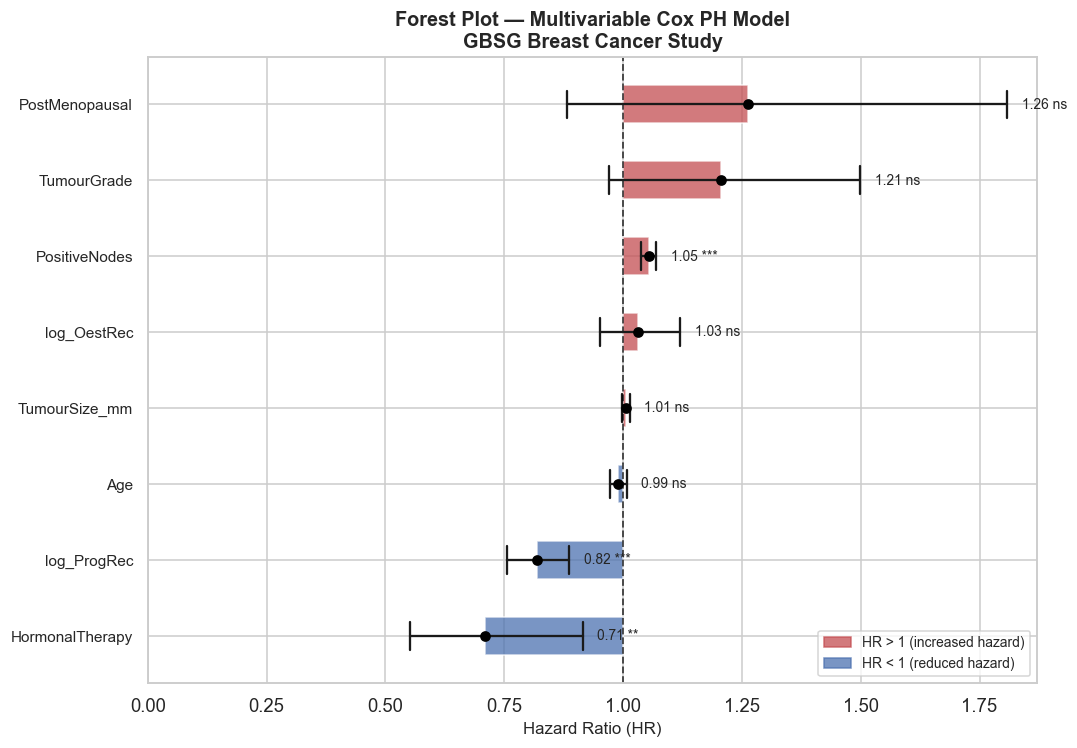

Plot saved under outputs/figures/
 Plot saved under outputs/figures/


In [12]:
# Extract multivariable HR estimates
mv_summary = cph.summary.copy()
mv_summary["HR"]    = np.exp(mv_summary["coef"])
mv_summary["lower"] = np.exp(mv_summary["coef lower 95%"])
mv_summary["upper"] = np.exp(mv_summary["coef upper 95%"])
mv_summary["sig"]   = mv_summary["p"].apply(
    lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
)
mv_summary = mv_summary.sort_values("HR", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = range(len(mv_summary))
colors = ["#C44E52" if hr > 1 else "#4C72B0" for hr in mv_summary["HR"]]

# Error bars (CI)
ax.barh(list(y_pos), mv_summary["HR"] - 1,
        left=1, height=0.5, color=colors, alpha=0.75, edgecolor="white")

# CI whiskers
for i, (_, row) in enumerate(mv_summary.iterrows()):
    ax.plot([row["lower"], row["upper"]], [i, i], "k-", linewidth=1.5, zorder=5)
    ax.plot([row["lower"], row["lower"]], [i - 0.18, i + 0.18], "k-", linewidth=1.5)
    ax.plot([row["upper"], row["upper"]], [i - 0.18, i + 0.18], "k-", linewidth=1.5)
    ax.plot(row["HR"], i, "o", color="black", markersize=6, zorder=6)
    # Label HR value
    ax.text(row["upper"] + 0.03, i, f"{row['HR']:.2f} {row['sig']}",
            va="center", fontsize=9)

ax.axvline(x=1, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(mv_summary.index, fontsize=10)
ax.set_xlabel("Hazard Ratio (HR)", fontsize=11)
ax.set_title("Forest Plot — Multivariable Cox PH Model\nGBSG Breast Cancer Study",
             fontweight="bold", fontsize=13)

red_patch  = mpatches.Patch(color="#C44E52", alpha=0.75, label="HR > 1 (increased hazard)")
blue_patch = mpatches.Patch(color="#4C72B0", alpha=0.75, label="HR < 1 (reduced hazard)")
ax.legend(handles=[red_patch, blue_patch], fontsize=9, loc="lower right")
ax.set_xlim(left=0)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/Forest_Plot — Multivariable_Cox_PH_Model.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Plot saved under outputs/figures/")

print(" Plot saved under outputs/figures/")

---
## 4. Partial Effects on Outcome (Survival Curves from Cox Model)

We can use the fitted Cox model to plot **adjusted survival curves** for specific
covariates, holding all others at their mean value. This is more informative than
raw KM curves because it accounts for confounders.

Tumour Grade plot saved.
Hormonal Therapy plot saved.


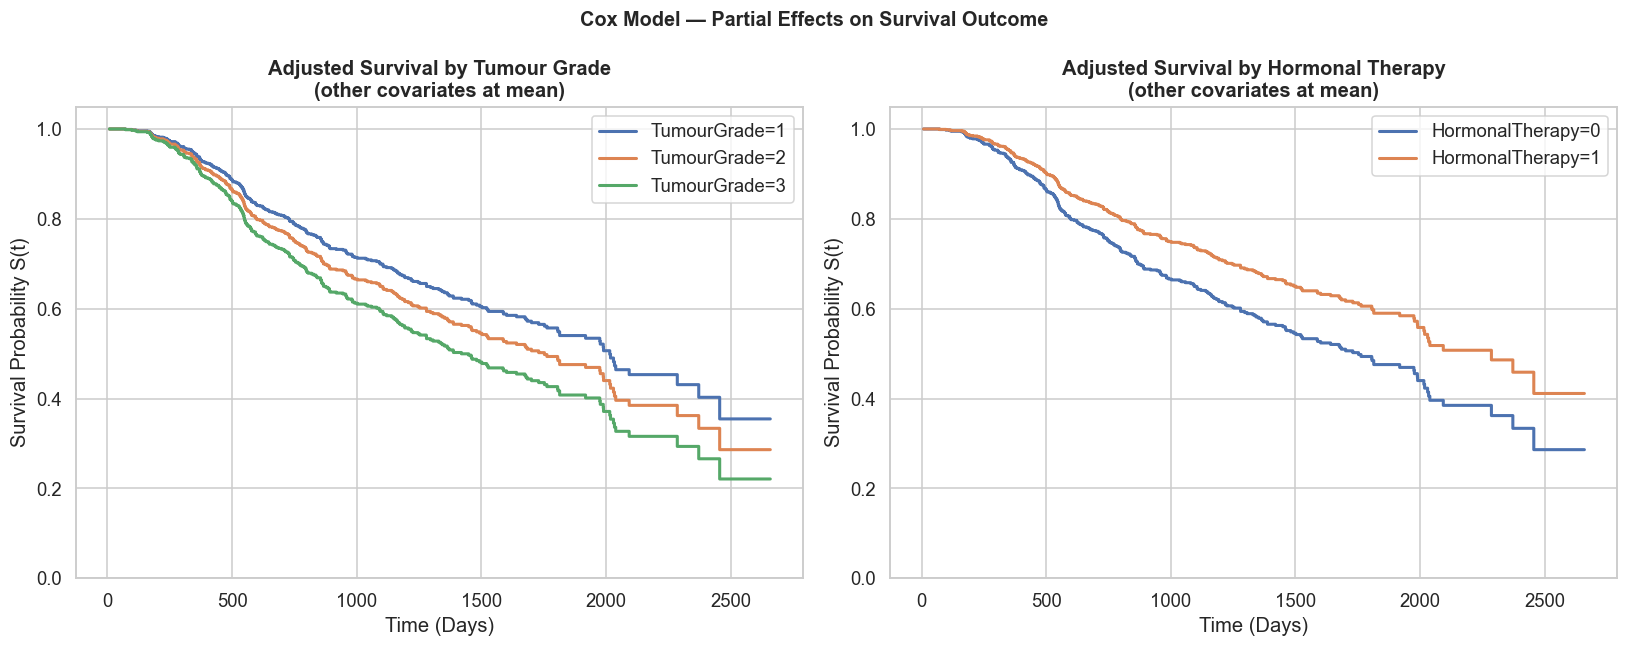

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Effect of Tumour Grade ---
cph.plot_partial_effects_on_outcome(
    covariates="TumourGrade",
    values=[1, 2, 3],
    ax=axes[0],
    plot_baseline=False,
    lw=2
)
axes[0].set_title("Adjusted Survival by Tumour Grade\n(other covariates at mean)",
                   fontweight="bold")
axes[0].set_xlabel("Time (Days)")
axes[0].set_ylabel("Survival Probability S(t)")
axes[0].set_ylim(0, 1.05)

# --- Effect of Hormonal Therapy ---
cph.plot_partial_effects_on_outcome(
    covariates="HormonalTherapy",
    values=[0, 1],
    ax=axes[1],
    plot_baseline=False,
    lw=2
)
axes[1].set_title("Adjusted Survival by Hormonal Therapy\n(other covariates at mean)",
                   fontweight="bold")
axes[1].set_xlabel("Time (Days)")
axes[1].set_ylabel("Survival Probability S(t)")
axes[1].set_ylim(0, 1.05)

plt.suptitle("Cox Model — Partial Effects on Survival Outcome",
             fontsize=13, fontweight="bold")
plt.tight_layout()

# Save as Tumour Grade
plt.savefig(
    "../outputs/figures/Adjusted_Survival_by_Tumour_Grade.png",
    dpi=300,
    bbox_inches="tight"
)
print("Tumour Grade plot saved.")

# Save same figure as Hormonal Therapy
plt.savefig(
    "../outputs/figures/Adjusted_Survival_by_Hormonal_Therapy.png",
    dpi=300,
    bbox_inches="tight"
)
print("Hormonal Therapy plot saved.")

plt.show()

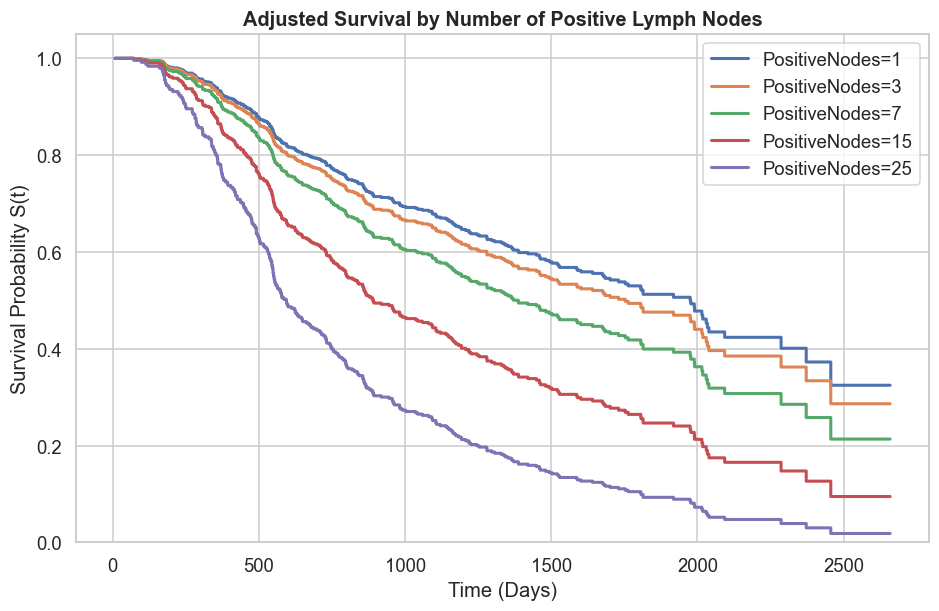

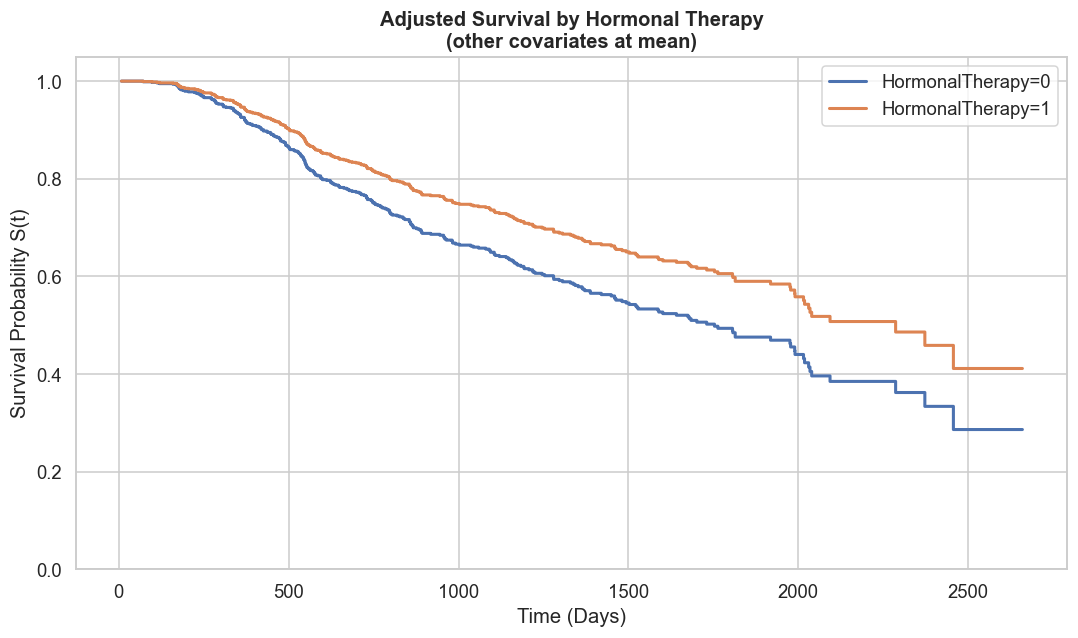

Plot saved under outputs/figures/


In [14]:
# ── Adjusted Survival by Positive Lymph Nodes ────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot_partial_effects_on_outcome(
    covariates="PositiveNodes",
    values=[1, 3, 7, 15, 25],
    ax=ax,
    plot_baseline=False,
    lw=2
)
ax.set_title("Adjusted Survival by Number of Positive Lymph Nodes",
             fontweight="bold", fontsize=13)
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Survival Probability S(t)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/Adjusted_Survival_by_Number_of_Positive_Lymph_Nodes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Positive Lymph Nodes plot saved.")

# ── Adjusted Survival by Hormonal Therapy ────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot_partial_effects_on_outcome(
    covariates="HormonalTherapy",
    values=[0, 1],
    ax=ax,
    plot_baseline=False,
    lw=2
)
ax.set_title("Adjusted Survival by Hormonal Therapy\n(other covariates at mean)",
             fontweight="bold")
ax.set_xlabel("Time (Days)")
ax.set_ylabel("Survival Probability S(t)")
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/Adjusted_Survival_by_Hormonal_Therapy.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
print("Hormonal Therapy plot saved.")

---
## ✅ Notebook 3 Summary

| Predictor | HR (multivariable) | Interpretation |
|-----------|-------------------|----------------|
| HormonalTherapy | < 1 (protective) | Reduces hazard — beneficial treatment |
| TumourGrade | > 1 (harmful) | Higher grade = higher hazard |
| PositiveNodes | > 1 (harmful) | Each additional node increases hazard |
| log_ProgRec | < 1 (protective) | Higher progesterone receptor = better survival |
| TumourSize_mm | > 1 (harmful) | Larger tumours = worse survival |

**Model Performance**: Concordance index ~0.66–0.68 (moderate — typical for clinical data)

> ⚠️ Before trusting these results, we must **verify the proportional hazards assumption**
> and check model diagnostics in Notebook 4.

